# Comparacion de Modelos

Resumen comparativo de los 4 modelos entrenados.

**Importante:** Arbol de Decision y SVM predicen `is_hit` (exito comercial binario).
MLP predice `imdb_clase` (calidad percibida en 3 clases). Son problemas complementarios, no directamente comparables.

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

import tensorflow as tf
from sklearn.metrics import roc_auc_score, RocCurveDisplay, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from src.preprocessing import codificar_categoricas, COLUMNAS_CATEGORICAS, COLUMNAS_NUMERICAS

## 1. Cargar datos y modelos

In [2]:
X_test_clf = pd.read_csv('../data/processed/X_test_clf.csv')
y_test_clf = pd.read_csv('../data/processed/y_test_clf.csv').squeeze()

# Reconstruir test set NN con RT score (mismo split que notebook 05)
df = pd.read_csv('../data/processed/catalogo_procesado.csv')
df, encoders = codificar_categoricas(df, COLUMNAS_CATEGORICAS)
FEATURES_NN_TF = COLUMNAS_NUMERICAS + ['platform_cod', 'primary_genre_cod', 'rating_cod', 'rotten_tomatoes_score']
df['imdb_clase_cod'] = df['imdb_clase'].map({'Bajo': 0, 'Medio': 1, 'Alto': 2})
X_all = df[FEATURES_NN_TF].values
y_all = df['imdb_clase_cod'].values
_, X_test_nn_raw, _, y_test_nn = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)
scaler_nn = joblib.load('../models/scaler_nn.joblib')
X_test_nn = scaler_nn.transform(X_test_nn_raw)

dt  = joblib.load('../models/decision_tree.joblib')
svm = joblib.load('../models/svm.joblib')
mlp = tf.keras.models.load_model('../models/mlp.keras')
print('Modelos cargados')
print(f'X_test_clf: {X_test_clf.shape}  |  X_test_nn: {X_test_nn.shape}')

Modelos cargados
X_test_clf: (3000, 17)  |  X_test_nn: (3000, 17)


## 2. Calcular metricas

In [3]:
# DT y SVM: target is_hit (binario)
y_pred_dt   = dt.predict(X_test_clf)
y_proba_dt  = dt.predict_proba(X_test_clf)[:, 1]
y_pred_svm  = svm.predict(X_test_clf)
y_proba_svm = svm.predict_proba(X_test_clf)[:, 1]

# MLP TF: target imdb_clase (multiclase)
y_proba_mlp = mlp.predict(X_test_nn, verbose=0)
y_pred_mlp  = y_proba_mlp.argmax(axis=1)

tabla = pd.DataFrame([
    {'Modelo': 'Arbol de Decision', 'Target': 'is_hit',
     'Accuracy': round(float(accuracy_score(y_test_clf, y_pred_dt)), 4),
     'F1-weighted': round(float(f1_score(y_test_clf, y_pred_dt, average='weighted')), 4),
     'ROC-AUC': round(float(roc_auc_score(y_test_clf, y_proba_dt)), 4)},
    {'Modelo': 'SVM', 'Target': 'is_hit',
     'Accuracy': round(float(accuracy_score(y_test_clf, y_pred_svm)), 4),
     'F1-weighted': round(float(f1_score(y_test_clf, y_pred_svm, average='weighted')), 4),
     'ROC-AUC': round(float(roc_auc_score(y_test_clf, y_proba_svm)), 4)},
    {'Modelo': 'MLP (TensorFlow)', 'Target': 'imdb_clase',
     'Accuracy': round(float(accuracy_score(y_test_nn, y_pred_mlp)), 4),
     'F1-weighted': round(float(f1_score(y_test_nn, y_pred_mlp, average='weighted')), 4),
     'ROC-AUC': '- (multiclase)'},
])
print(tabla.to_string(index=False))

           Modelo     Target  Accuracy  F1-weighted        ROC-AUC
Arbol de Decision     is_hit     0.914       0.9140         0.9717
              SVM     is_hit     0.912       0.9120         0.9752
 MLP (TensorFlow) imdb_clase     0.676       0.6707 - (multiclase)


## 3. Curvas ROC superpuestas (DT vs SVM)

Comparable porque ambos predicen `is_hit` en el mismo test set.

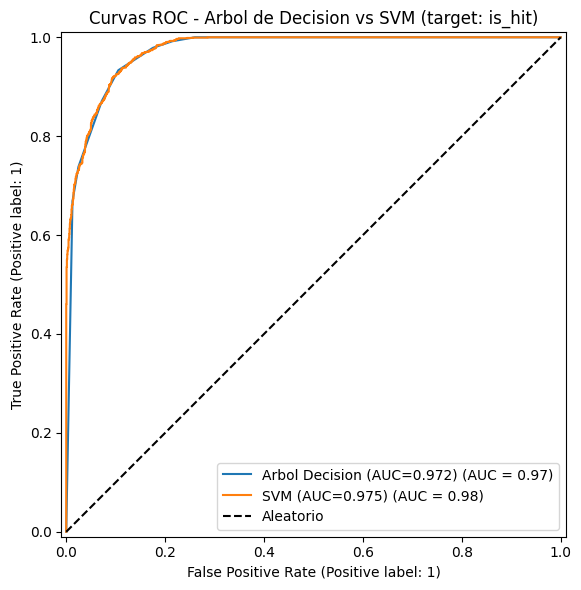

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test_clf, y_proba_dt,
    name=f'Arbol Decision (AUC={roc_auc_score(y_test_clf, y_proba_dt):.3f})', ax=ax
)
RocCurveDisplay.from_predictions(
    y_test_clf, y_proba_svm,
    name=f'SVM (AUC={roc_auc_score(y_test_clf, y_proba_svm):.3f})', ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title('Curvas ROC - Arbol de Decision vs SVM (target: is_hit)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/21_roc_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. MLP: F1 por clase (Bajo / Medio / Alto)

In [5]:
from sklearn.metrics import classification_report
print(classification_report(y_test_nn, y_pred_mlp, target_names=['Bajo', 'Medio', 'Alto']))

              precision    recall  f1-score   support

        Bajo       0.63      0.83      0.71       830
       Medio       0.74      0.55      0.63      1504
        Alto       0.66      0.78      0.71       666

    accuracy                           0.68      3000
   macro avg       0.67      0.72      0.68      3000
weighted avg       0.69      0.68      0.67      3000



## 5. Guardar metricas consolidadas

In [6]:
metricas = {
    'decision_tree': {
        'modelo': 'Arbol de Decision', 'target': 'is_hit',
        'accuracy': round(float(accuracy_score(y_test_clf, y_pred_dt)), 4),
        'f1_weighted': round(float(f1_score(y_test_clf, y_pred_dt, average='weighted')), 4),
        'roc_auc': round(float(roc_auc_score(y_test_clf, y_proba_dt)), 4),
    },
    'svm': {
        'modelo': 'SVM', 'target': 'is_hit',
        'accuracy': round(float(accuracy_score(y_test_clf, y_pred_svm)), 4),
        'f1_weighted': round(float(f1_score(y_test_clf, y_pred_svm, average='weighted')), 4),
        'roc_auc': round(float(roc_auc_score(y_test_clf, y_proba_svm)), 4),
    },
    'mlp': {
        'modelo': 'Red Neuronal (TensorFlow)', 'target': 'imdb_clase',
        'accuracy': round(float(accuracy_score(y_test_nn, y_pred_mlp)), 4),
        'f1_macro': round(float(f1_score(y_test_nn, y_pred_mlp, average='macro')), 4),
        'f1_weighted': round(float(f1_score(y_test_nn, y_pred_mlp, average='weighted')), 4),
        'incluye_rt_score': True,
    },
}

with open('../models/metricas.json', 'w', encoding='utf-8') as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)
print('Guardado: models/metricas.json')
print(json.dumps(metricas['mlp'], indent=2))

Guardado: models/metricas.json
{
  "modelo": "Red Neuronal (TensorFlow)",
  "target": "imdb_clase",
  "accuracy": 0.676,
  "f1_macro": 0.6844,
  "f1_weighted": 0.6707,
  "incluye_rt_score": true
}
